# 이변수 데이터 분석

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import platform

if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='DejaVu Sans')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('NumPy 버전:', np.__version__)
print('환경 설정 완료')

NumPy 버전: 2.3.5
환경 설정 완료


- kobis 데이터 로드

In [2]:
kobis_df = pd.read_csv('data/kobis.csv')
kobis_df.head()
kobis_df.shape
kobis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   날짜      3650 non-null   int64 
 1   순위      3650 non-null   int64 
 2   영화명     3650 non-null   object
 3   개봉일     3650 non-null   object
 4   일일관객수   3650 non-null   int64 
 5   누적관객수   3650 non-null   int64 
 6   일일매출액   3650 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 199.7+ KB


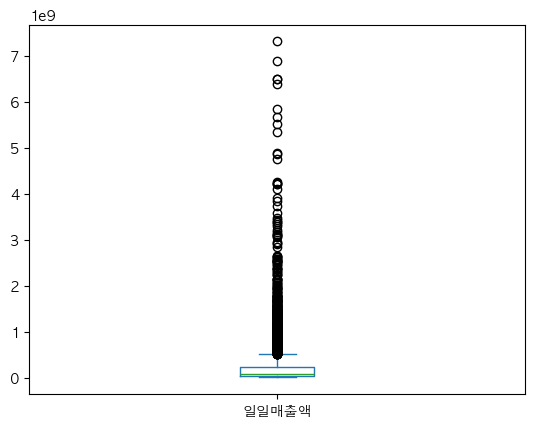

In [3]:
kobis_df['일일매출액'].value_counts()
kobis_df['일일매출액'].plot.box()
plt.show()

In [4]:
kobis_df['일일관객수'].value_counts()

일일관객수
3068     4
5250     4
2914     3
2462     3
1604     3
        ..
10486    1
6125     1
6110     1
4650     1
4051     1
Name: count, Length: 3372, dtype: int64

In [5]:
# 일일매출액, 일일관객수의 평균값, 중앙값
kobis_df[['일일매출액','일일관객수']].mean()
kobis_df[['일일매출액','일일관객수']].median()
kobis_df[['일일매출액','일일관객수']].agg(['mean', 'median'])

,일일매출액,일일관객수
mean,2.652728e+08,26874.885753
median,7.086890e+07,7320.000000


In [6]:
kobis_df.describe()

,날짜,순위,일일관객수,누적관객수,일일매출액
count,3.650000e+03,3650.000000,3650.000000,3.650000e+03,3.650000e+03
mean,2.025067e+07,5.500000,26874.885753,9.613494e+05,2.652728e+08
std,3.450492e+02,2.872675,56635.799237,1.444113e+06,5.748500e+08
min,2.025010e+07,1.000000,519.000000,1.048000e+03,2.230000e+06
25%,2.025040e+07,3.000000,3314.500000,5.198450e+04,3.121042e+07
50%,2.025070e+07,5.500000,7320.000000,2.928320e+05,7.086890e+07
75%,2.025100e+07,8.000000,23301.000000,1.200541e+06,2.236650e+08
max,2.025123e+07,10.000000,700790.000000,1.080952e+07,7.314982e+09


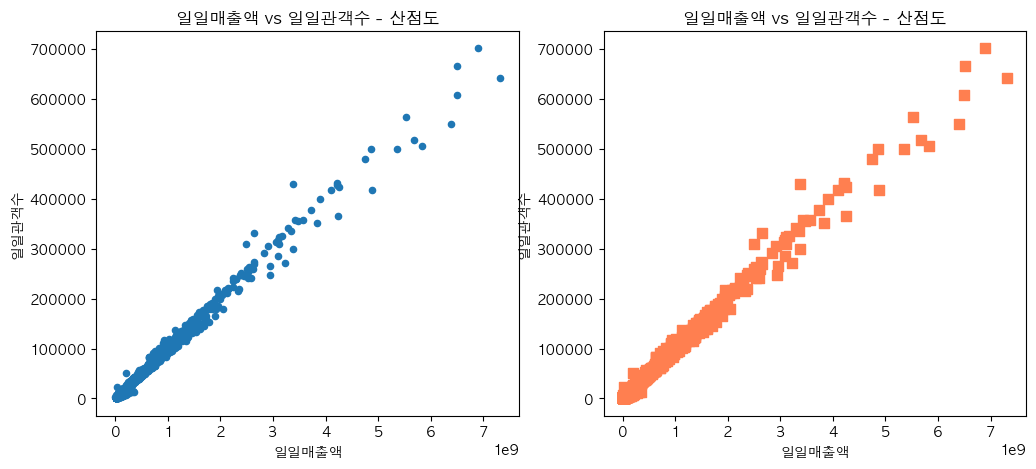

In [7]:
# 일일매출액, 일일관객수의 상관관계에 따른 산점도
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

kobis_df.plot.scatter(
    ax = axes[0],
    x='일일매출액',
    y='일일관객수',
    title='일일매출액 vs 일일관객수 - 산점도'
)
kobis_df.plot.scatter(
    ax = axes[1],
    x='일일매출액',
    y='일일관객수',
    marker='s',
    s=50,
    c='coral',
    title='일일매출액 vs 일일관객수 - 산점도'
)
plt.show()

In [8]:
# 일일매출액과 일일관객수의 상관계수
r = kobis_df['일일매출액'].corr(kobis_df['일일관객수'])
print(f"r(상관계수): {r:.3f}")  ## 이상치 데이터에 영향을 받음

r(상관계수): 0.996


#### mpg 데이터셋을 분석하여 무게(weight)와 연비(mpg)의 상관관계 분석

- mpg 데이터셋 로드

In [17]:
# 데이터 로드, 정보 확인
mpg_df = pd.read_csv('data/mpg.csv')
mpg_df.head()
mpg_df.shape
mpg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [18]:
mpg_df[['mpg', 'weight']].describe()

,mpg,weight
count,398.000000,398.000000
mean,23.514573,2970.424623
std,7.815984,846.841774
min,9.000000,1613.000000
25%,17.500000,2223.750000
50%,23.000000,2803.500000
75%,29.000000,3608.000000
max,46.600000,5140.000000


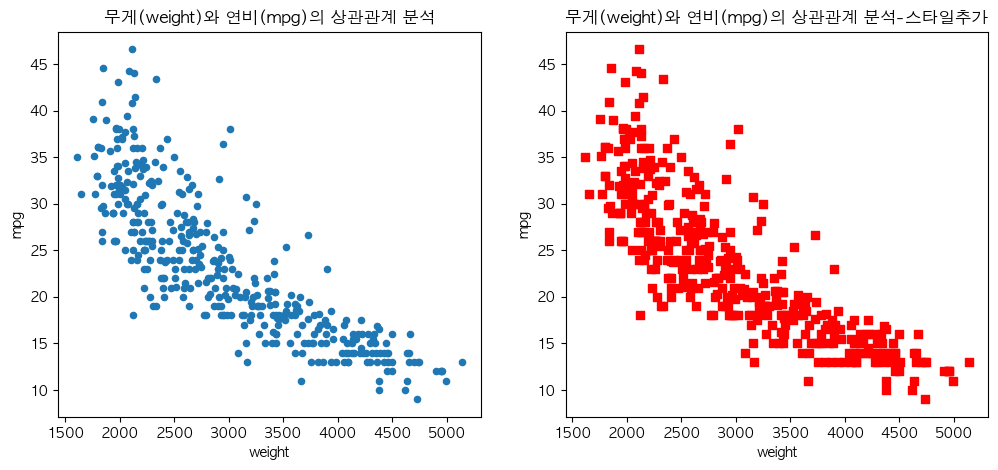

In [19]:
# 산점도 시각화

# 한 행에 그래프 2개 작성
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mpg_df.plot.scatter(
    ax = axes[0],
    x='weight',
    y='mpg',
    title='무게(weight)와 연비(mpg)의 상관관계 분석'
)
mpg_df.plot.scatter(
    ax = axes[1],
    x='weight',
    y='mpg',
    marker='s',
    s=30,
    c='red',
    title='무게(weight)와 연비(mpg)의 상관관계 분석-스타일추가'
)
plt.show()

In [20]:
# 무게와 연비의 상관계수 구하기
r = mpg_df['weight'].corr(mpg_df['mpg'])
print(f"r(상관계수) : {r:.3f}")

r(상관계수) : -0.832


#### mpg 컬럼에 이상치 데이터를 추가하면??

23.514572864321607
23.0


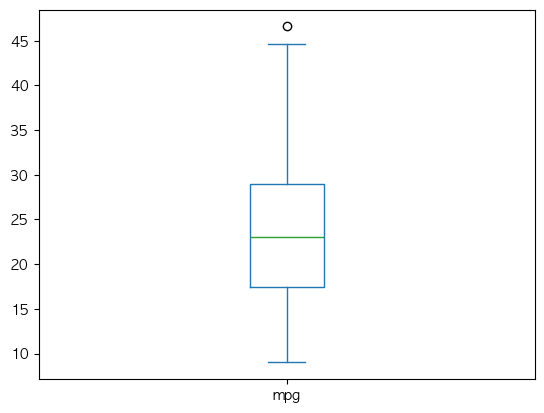

In [21]:
print(mpg_df['mpg'].mean())
print(mpg_df['mpg'].median())
mpg_df['mpg'].plot.box()
plt.show()

In [22]:
# 0번지 데이터의 mpg 10000 으로 변경
mpg_df.loc[0,'mpg'] = 10000
mpg_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,10000.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


48.59497487437186
23.0


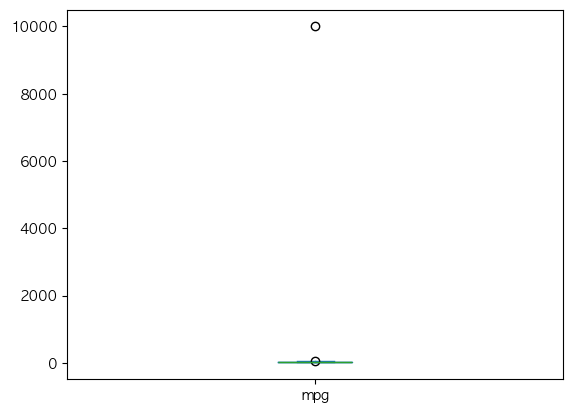

In [23]:
print(mpg_df['mpg'].mean())
print(mpg_df['mpg'].median())
mpg_df['mpg'].plot.box()
plt.show()

In [24]:
# 무게와 연비의 상관계수 구하기
r = mpg_df['weight'].corr(mpg_df['mpg'])
print(f"r(상관계수) : {r:.3f}")

r(상관계수) : 0.019


In [25]:
## 이상치 조정 -> 삭제(drop함수), 중앙값(median()), 이전값(ffill()), 다음값(bfill())
mpg_df.loc[0, 'mpg'] = mpg_df['mpg'].median()
mpg_df.head(3)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,23.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite


In [26]:
# 무게와 연비의 상관계수 구하기
r = mpg_df['weight'].corr(mpg_df['mpg'])
print(f"r(상관계수) : {r:.3f}")

r(상관계수) : -0.831


#### iris 데이터셋의 꽃잎길이(PetalLength)와 꽃잎넓이(PetalWidth)의 상관관계 도출

In [27]:
# 데이터셋 로드
iris_df = pd.read_csv('data/iris.csv')
iris_df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [28]:
# 결측치 확인
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [29]:
# 통계지표 확인
iris_df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [30]:
# 상관 계수 도출
r = iris_df['PetalLengthCm'].corr(iris_df['PetalWidthCm'])
print(f"r : {r:.3f}")

r : 0.963


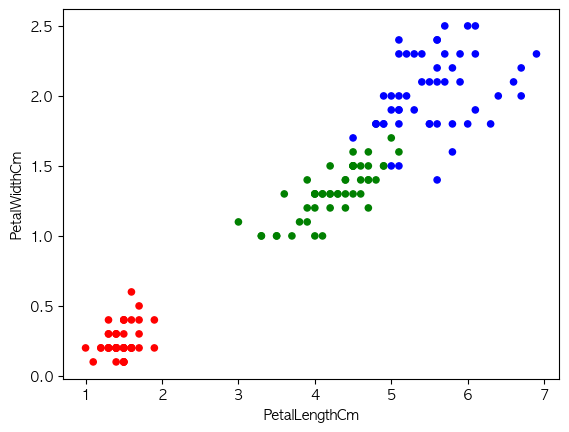

In [31]:
# 산점도 그래프 생성
colors = {
    "Iris-setosa" : "red",
    "Iris-versicolor" : "green",
    "Iris-virginica" : "blue"
}
colors = [colors[sp] for sp in iris_df.Species]
iris_df.plot.scatter(
    x = 'PetalLengthCm',
    y = 'PetalWidthCm',
    c = colors,
    s = 20
)
plt.show()

#### 타이타닉 데이터셋의 나이와 요금의 상관 관계 도출

In [32]:
# 데이터셋 로드
td = pd.read_csv('data/titanic/train.csv')
td.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [33]:
# 상위 5개 확인
td.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [34]:
# 데이터타입, 결측치 확인 등..
td.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [35]:
# 결측치 데이터 갯수
td.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [36]:
# 통계지표 확인
td[['Age','Fare']].describe()

,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


In [37]:
# 'Age' 컬럼의 결측치 => 평균으로 대체
td['Age'] = td['Age'].fillna(td['Age'].mean())

In [38]:
td.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [39]:
td.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


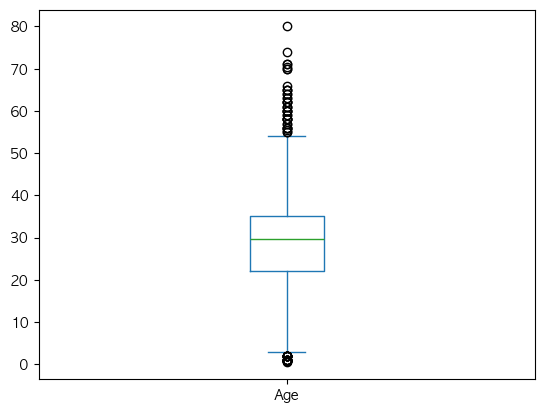

In [40]:
# 각 변수별 박스 플롯  생성
td['Age'].plot.box()
plt.show()

In [41]:
td['Fare'].agg(['min','max', 'mean', 'median'])

min         0.000000
max       512.329200
mean       32.204208
median     14.454200
Name: Fare, dtype: float64

<Axes: >

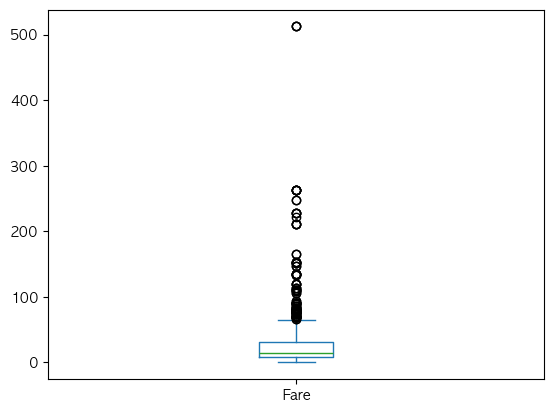

In [42]:
# 각 변수별 박스 플롯  생성
td['Fare'].plot.box()

In [43]:
# td.query('Fare >= 500')['Fare'] = td['Fare'].median()
td.query('Fare >= 500')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C


In [44]:
td.loc[679, 'Fare'] = td['Fare'].median()
td.loc[737, 'Fare'] = td['Fare'].median()

In [45]:
# 나이, 요금의 상관 계수 구하기
r = td['Age'].corr(td['Fare'])
print(f"r : {r : .3f}")

r :  0.092


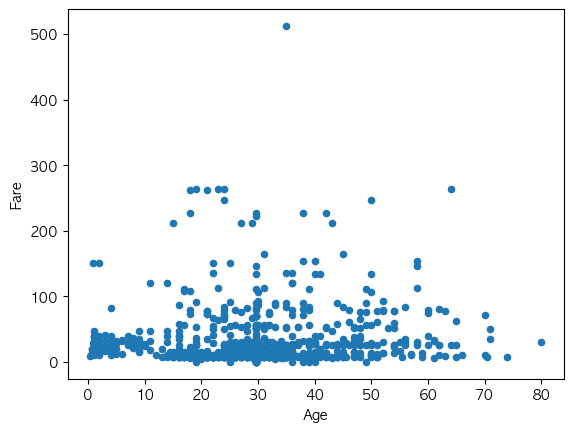

In [46]:
# 산점도 그래프 생성
td.plot.scatter(
    x ='Age',
    y ='Fare'
)
plt.show()

#### 회귀선

In [47]:
iris_df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [48]:
# 양의 상관 관계를 가지는 데이터셋 기준
# numpy.polyfit() 기울기, 절편
# y = mx + b
m, b = np.polyfit(iris_df['PetalLengthCm'], iris_df['PetalWidthCm'], 1)
print(m, b)

0.4164191322854009 -0.36651404521672726


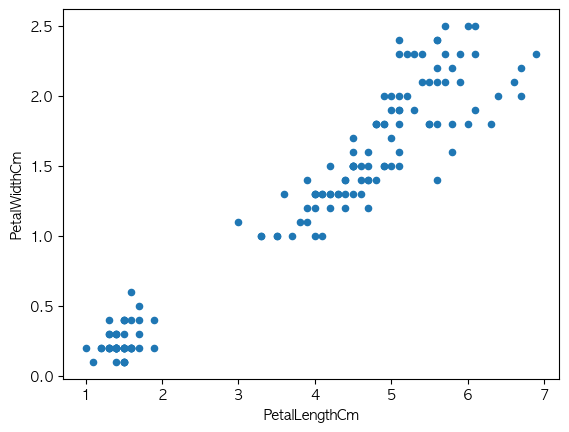

In [49]:
# Iris PetalLength, PetalWidth 산점도
iris_df.plot.scatter(
    x='PetalLengthCm',
    y='PetalWidthCm'
)
plt.show()

In [50]:
# Iris PetalLength, PetalWidth 회귀선
print(m, b)

0.4164191322854009 -0.36651404521672726


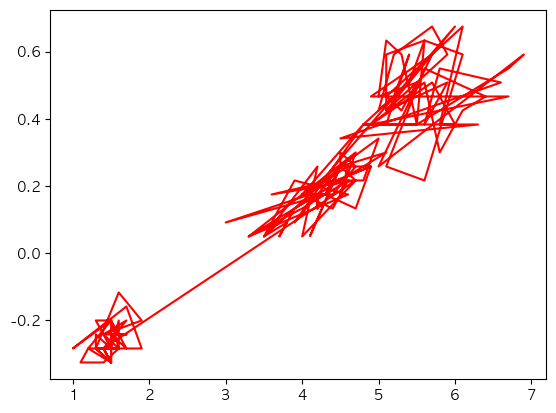

In [51]:
# Iris PetalLength, PetalWidth 회귀선
plt.plot(
    iris_df['PetalLengthCm'],
    m*iris_df['PetalWidthCm'] + b,
    color='red'
)
plt.show()

#### Seaborn 패키지를 통한 시각화

In [52]:
# 패키지 임포트
import seaborn as sns

In [53]:
iris_df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


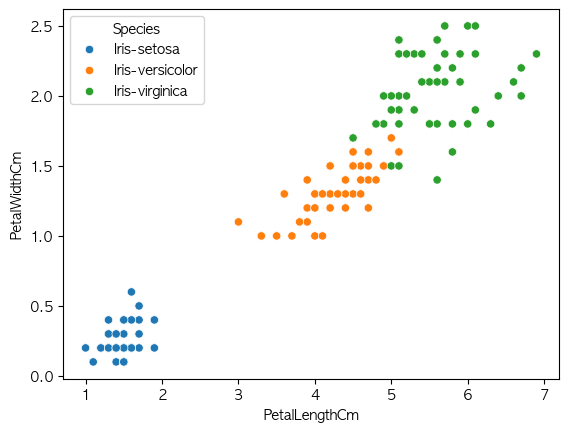

In [54]:
# 1. 산점도 - seaborn.scatterplot()
sns.scatterplot(
    data = iris_df,
    x = 'PetalLengthCm',
    y = 'PetalWidthCm',
    hue = 'Species' # 그룹핑
)
plt.show()

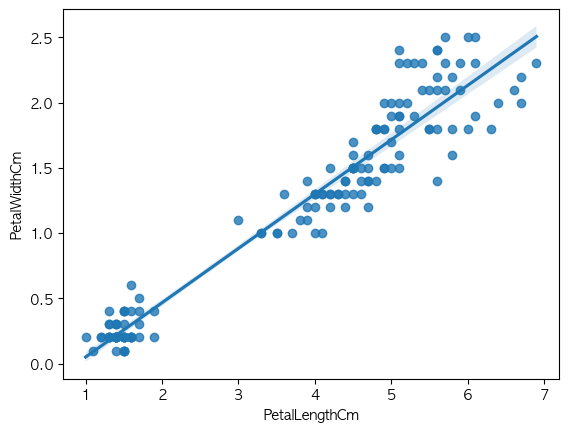

In [55]:
# 2. 산점도 + 회귀선 - seaborn.regplot()

sns.regplot(
    data = iris_df,
    x = 'PetalLengthCm',
    y = 'PetalWidthCm'
)
plt.show()

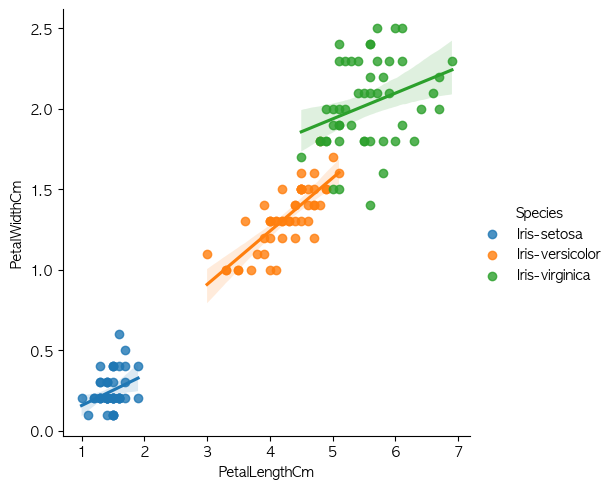

In [56]:
# 3. 산점도 + 회귀선(그룹핑) - seaborn.lmplot()
sns.lmplot(
    data = iris_df,
    x = 'PetalLengthCm',
    y = 'PetalWidthCm',
    hue = 'Species'
)
plt.show()

#### 회귀식의 기울기와 절편을 이용하여 데이터 예측하기
- 회귀식 : y = mx + b
- x: (예측값)독립변수, (예측값)y: 종속변수, m: 기울기, b: 절편
  예) 꽃잎의 넓이: 1.2 일때, 꽃잎의 길이를 구한다면? 1.5  

### 기온에 따른 따릉이 대여건수 산점도, 상관계수, 회귀식 도출
- 따릉이 데이터 + 날씨 데이터

#### (1) 데이터 준비

In [57]:
# 데이터셋 로드 - 따릉이
df1 = pd.read_csv('data/서울특별시 공공자전거 일별 대여건수_25.1-6.csv')
df1.head()

,대여일자,대여건수
0,2025-01-01,48645
1,2025-01-02,77718
2,2025-01-03,77053
3,2025-01-04,56597
4,2025-01-05,19712


In [59]:
# 데이터셋 로드 - 날씨
df2 = pd.read_csv('data/OBS_ASOS_DD_20250101.csv')
df2.head()

,지점,지점명,일시,평균기온(°C)
0,108,서울,2025-01-01,2.6
1,108,서울,2025-01-02,0.5
2,108,서울,2025-01-03,-1.1
3,108,서울,2025-01-04,-0.1
4,108,서울,2025-01-05,1.2


In [60]:
print(df1.info(), '\n', df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   대여일자    181 non-null    object
 1   대여건수    181 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 3.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   지점        181 non-null    int64  
 1   지점명       181 non-null    object 
 2   일시        181 non-null    object 
 3   평균기온(°C)  181 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 5.8+ KB
None 
 None


#### (2) 데이터 타입 및 컬럼명 변경

In [61]:
# df1, df2 데이터 타입 변경 - to_datetime()
df1['대여일자'] = pd.to_datetime(df1['대여일자'])
df2['일시'] = pd.to_datetime(df2['일시'])

In [62]:
print(df1['대여일자'].dtypes)
print(df2['일시'].dtypes)

datetime64[ns]
datetime64[ns]


In [63]:
# df1, df2 컬럼명 변경 - rename()
df1.rename( columns = {'대여일자':'날짜'}, inplace=True)
df2.rename( columns = {'일시':'날짜', '평균기온(°C)': '기온'}, inplace=True)
print(df1.head(3), '\n', df2.head(3))

          날짜   대여건수
0 2025-01-01  48645
1 2025-01-02  77718
2 2025-01-03  77053 
     지점 지점명         날짜   기온
0  108  서울 2025-01-01  2.6
1  108  서울 2025-01-02  0.5
2  108  서울 2025-01-03 -1.1


#### (3) 데이터 합치기(Merge)

In [64]:
df = pd.merge(df1, df2, how='inner', on='날짜')
df.head()

,날짜,대여건수,지점,지점명,기온
0,2025-01-01,48645,108,서울,2.6
1,2025-01-02,77718,108,서울,0.5
2,2025-01-03,77053,108,서울,-1.1
3,2025-01-04,56597,108,서울,-0.1
4,2025-01-05,19712,108,서울,1.2


#### (4) 결측치, 이상치, 통계 지표 등.. 확인

In [65]:
# 결측치 확인
df.isna().sum()

날짜      0
대여건수    0
지점      0
지점명     0
기온      0
dtype: int64

In [66]:
# 통계지표 확인
df[['기온', '대여건수']].describe()

,기온,대여건수
count,181.000000,181.000000
mean,10.364641,97930.000000
std,9.882323,45667.771553
min,-9.700000,13179.000000
25%,2.300000,58107.000000
50%,11.200000,99722.000000
75%,19.400000,137711.000000
max,28.200000,173915.000000


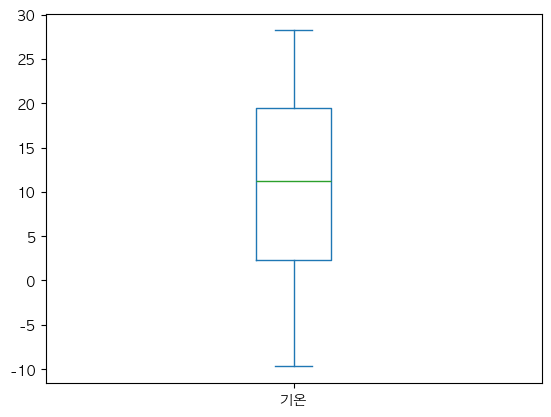

In [67]:
# 박스 플롯으로 이상치 확인
df['기온'].plot.box()
plt.show()

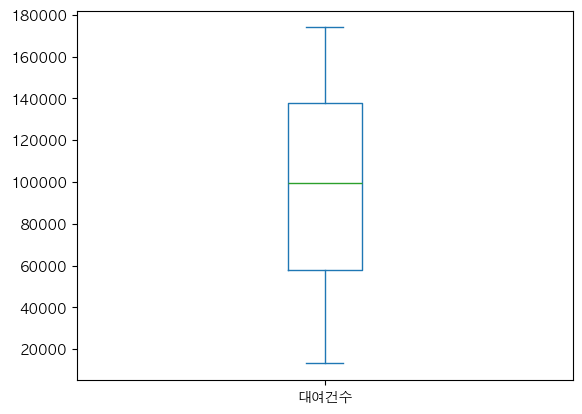

In [68]:
# 박스 플롯으로 이상치 확인
df['대여건수'].plot.box()
plt.show()

#### (5) 상관계수

In [69]:
r = df['기온'].corr(df['대여건수'])
print(f"r : {r:.3f}")

r : 0.750


#### (6) 산점도

In [70]:
# seaborn 패키지 사용
import seaborn as sns


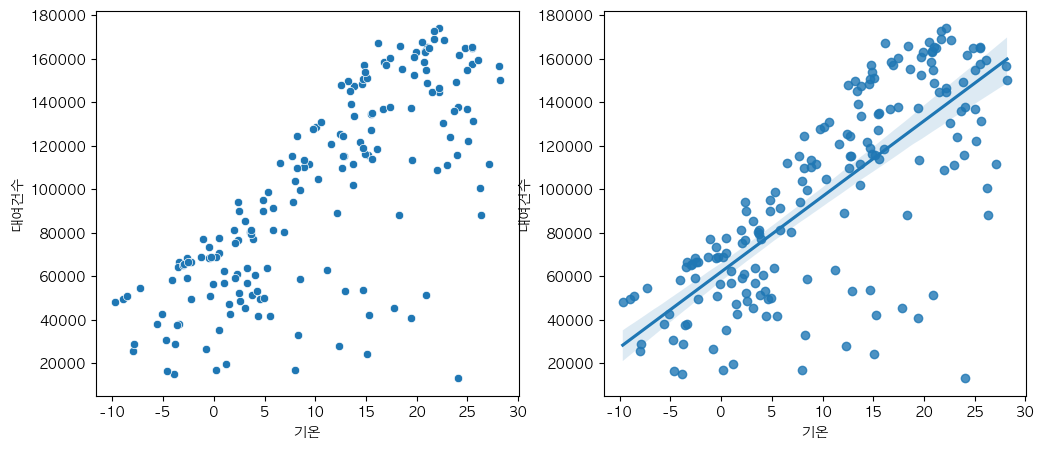

In [71]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 산점도
sns.scatterplot(
    x = '기온',
    y = '대여건수',
    data = df,
    ax = axes[0],
)

# 산점도 + 회귀선
sns.regplot(
    x = '기온',
    y = '대여건수',
    data = df,
    ax = axes[1],
)

# 산점도 + 회귀선 + 그룹핑
#sns.lmplot(
#    x = '기온',
#    y = '대여건수',
#    data = df,
#    ax = axes[2]
#    hue = '그룹핑 컬럼명'
#)

plt.show()

#### (7) 회귀식 구하기 
- y = mx + b
- m(기울기), b(절편)를 구하는 식 :  numpy.polyfit(x, y)
- 데이터 예측 가능

In [72]:
# m, b 구하기
m, b = np.polyfit(df['기온'], df['대여건수'], 1)
print(m, b)

3466.2810234466406 62003.241989028145


In [73]:
# 기온이 25일때 대여건수 얼마나 될까??
# 회귀식 : y(대여건수) = mx(기온) + b
x = 25
y = m*x + b
print(f"기온이 25일때 예측된 대여건수 : {y:.0f}")

기온이 25일때 예측된 대여건수 : 148660


In [74]:
df.query('기온 >= 25') # 154649  :: 예측 데이터 148660

,날짜,대여건수,지점,지점명,기온
140,2025-05-21,157494,108,서울,25.5
158,2025-06-08,122268,108,서울,25.1
162,2025-06-12,164824,108,서울,25.5
164,2025-06-14,131389,108,서울,25.6
165,2025-06-15,88162,108,서울,26.3
168,2025-06-18,165124,108,서울,25.5
169,2025-06-19,156770,108,서울,28.1
173,2025-06-23,159484,108,서울,26.1
174,2025-06-24,136677,108,서울,25.0
177,2025-06-27,154649,108,서울,25.0
